**Email Spam Detection Using Naive Bayes Classifier**

*Rahul Raha (22102043)*

**STEP 1 — Setup Environment**

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**STEP 2 — Loading dataset**

In [13]:
df = pd.read_csv("emails.csv")
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


**STEP 3 — EDA**

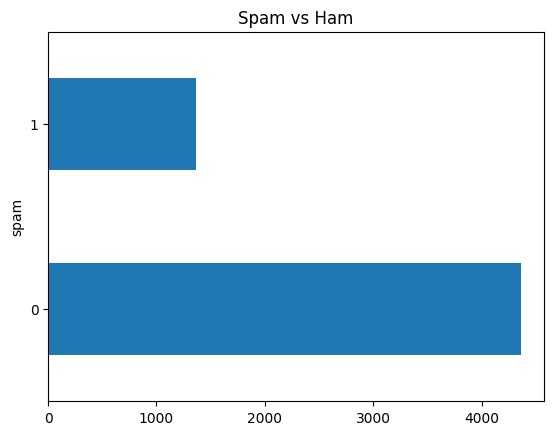

In [29]:
import matplotlib.pyplot as plt

df["spam"].value_counts().plot(kind="barh")
plt.title("Spam vs Ham")
plt.show()

In [16]:
df["length"] = df["text"].astype(str).apply(len)

df.groupby("spam")["length"].mean()

,length
spam,
0,1631.918119
1,1317.257310


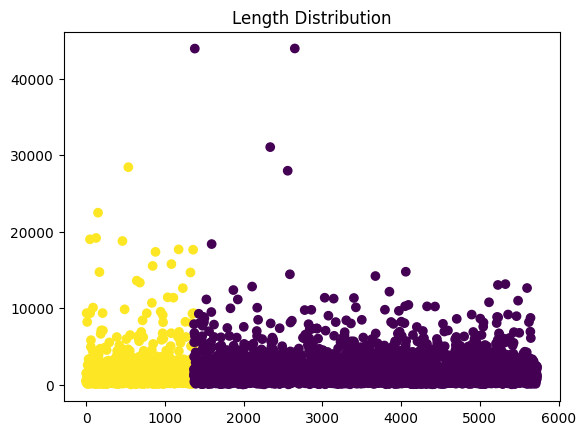

In [30]:
import matplotlib.pyplot as plt

plt.scatter(df.index, df["length"], c=df["spam"])
plt.title("Length Distribution")
plt.show()

STEP 4 — Text Cleaning

In [18]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'subject:', '', text)
    text = re.sub(r'[^a-z0-9 ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df["clean_text"] = df["text"].apply(clean_text)

**STEP 5 — TF-IDF (TEXT to NUMBERS)**

In [21]:

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X = vectorizer.fit_transform(df["clean_text"])
y = df["spam"]


STEP 6 **— Train-Test Split**

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**STEP 7 — Train Naive Bayes Model**

In [24]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


STEP 9 — Evaluation **bold text**

In [25]:

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       856
           1       0.96      0.94      0.95       290

    accuracy                           0.98      1146
   macro avg       0.97      0.97      0.97      1146
weighted avg       0.98      0.98      0.98      1146

[[846  10]
 [ 16 274]]


STEP 10 — Test with new **email**

In [26]:
def predict_email(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]s
    return "SPAM" if pred == 1 else "NOT SPAM"

print(predict_email("Win a brand new car by entering this contest today!"))

print(predict_email("Dear student, your exam schedule has been published."))

print(predict_email("Limited offer! Buy one get one free on all items. Hurry up!"))

print(predict_email("Hey, are we still meeting for the group study tonight?"))

print(predict_email("Your PayPal account needs verification. Login immediately."))

print(predict_email("Project deadline has been extended to next week."))

print(predict_email("Congratulations! You have been chosen for a cash reward."))

print(predict_email("Can you please share the updated report by evening?"))

print(predict_email("Lowest prices on electronics available now. Shop today!"))

print(predict_email("Your password was changed successfully. If not you, contact support."))

SPAM
NOT SPAM
SPAM
NOT SPAM
SPAM
NOT SPAM
NOT SPAM
NOT SPAM
SPAM
NOT SPAM
